In [1]:
!pip install yfinance pandas numpy matplotlib

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_2664/534828021.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [5]:
df.to_csv("apple_stock.csv")

In [7]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [8]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
1,2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2,2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [9]:
df_clean = df[["Date", "Close"]]
df_clean.head()

Price,Date,Close
Ticker,,AAPL
0,2020-01-02,72.333862
1,2020-01-03,71.630653
2,2020-01-06,72.201393
3,2020-01-07,71.861832
4,2020-01-08,73.017830


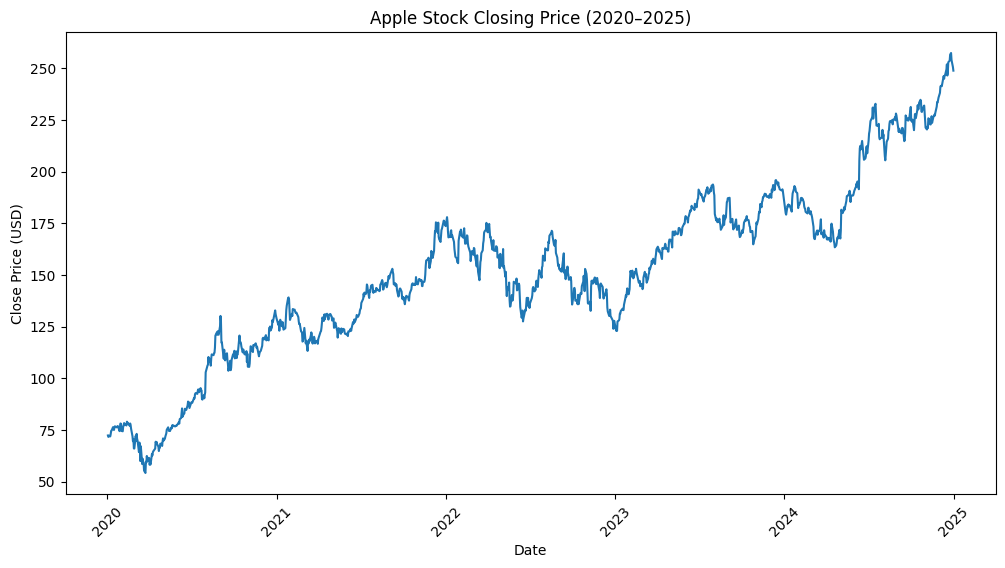

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_clean["Date"], df_clean["Close"])
plt.title("Apple Stock Closing Price (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.xticks(rotation=45)
plt.show()

In [11]:
df_clean["MA_50"] = df_clean["Close"].rolling(window=50).mean()
df_clean.head()

/tmp/ipykernel_2664/2618491641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["MA_50"] = df_clean["Close"].rolling(window=50).mean()


Price,Date,Close,MA_50
Ticker,,AAPL,
0,2020-01-02,72.333862,NaN
1,2020-01-03,71.630653,NaN
2,2020-01-06,72.201393,NaN
3,2020-01-07,71.861832,NaN
4,2020-01-08,73.017830,NaN


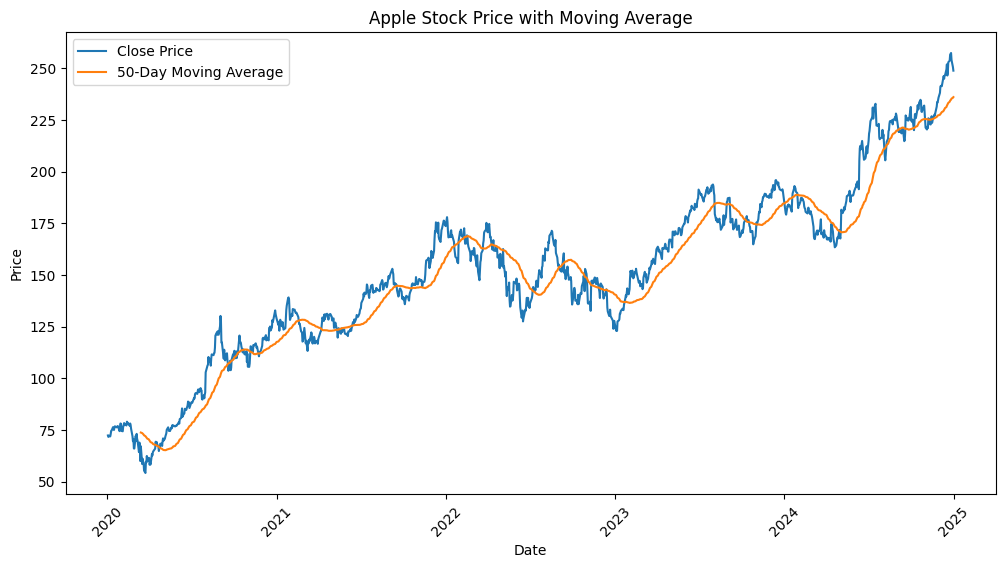

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df_clean["Date"], df_clean["Close"], label="Close Price")
plt.plot(df_clean["Date"], df_clean["MA_50"], label="50-Day Moving Average")

plt.title("Apple Stock Price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Insight 1 — Trend
Apple stock shows an overall increasing trend from 2020 to 2025 with short-term fluctuations.

Insight 2 — Volatility
Stock price is not stable; it has frequent ups and downs indicating market volatility.

Insight 3 — Moving Average Effect
The 50-day moving average smooths the curve and clearly shows long-term trend direction.

Insight 4 — Market behavior
Short-term price movements deviate from moving average but tend to return toward trend over time.